In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, matthews_corrcoef,
    cohen_kappa_score, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [2]:
# Metrics
def gmean_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    per_class = []
    for i in range(cm.shape[0]):
        tp = cm[i,i]
        fn = cm[i].sum() - tp
        fp = cm[:,i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        per_class.append(np.sqrt(sens * spec))
    return np.prod(per_class) ** (1/len(per_class)) if per_class else 0

def gmean_per_class(y_true, y_pred, target_class):
    cm = confusion_matrix(y_true, y_pred)
    i = target_class
    tp = cm[i,i]
    fn = cm[i].sum() - tp
    fp = cm[:,i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(recall * specificity)

def print_results(
    version_name,
    phase,
    y_true,
    y_pred,
    time_build_model=None,
    time_predict=None
):
    target_names = ['Excellent', 'Good', 'Average']

    print(f"\n{'='*30} {version_name} - Phase {phase} {'='*30}")
    print(classification_report(
        y_true,
        y_pred,
        digits=10,
        target_names=target_names
    ))

    # Precision / Recall / F1 theo từng class
    prec_per_class = precision_score(y_true, y_pred, average=None)
    rec_per_class  = recall_score(y_true, y_pred, average=None)
    f1_per_class   = f1_score(y_true, y_pred, average=None)

    # G-Mean per class
    gmean_classes = [
        gmean_per_class(y_true, y_pred, i)
        for i in range(len(target_names))
    ]

    print("G-Mean per class (one-vs-rest):")
    for idx, name in enumerate(target_names):
        print(f"  {name:<10}: {gmean_classes[idx]:.10f}")
        
    print()

    # ===== TẠO DICTIONARY METRICS =====
    metrics = {
        'Version': version_name,
        'Phase': phase,

        'TimeBuildModel': time_build_model,
        'TimePredict': time_predict,

        'Accuracy': accuracy_score(y_true, y_pred),
        'BalancedAcc': balanced_accuracy_score(y_true, y_pred),

        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'Precision Weighted': precision_score(y_true, y_pred, average='weighted'),

        'Recall Macro': recall_score(y_true, y_pred, average='macro'),
        'Recall Weighted': recall_score(y_true, y_pred, average='weighted'),

        'F1-Score Macro': f1_score(y_true, y_pred, average='macro'),
        'F1-Score Weighted': f1_score(y_true, y_pred, average='weighted'),

        'GMean': gmean_score(y_true, y_pred),

        'MCC': matthews_corrcoef(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred),
    }

    # ===== THÊM METRIC CHO TỪNG CLASS =====
    for i, name in enumerate(target_names):
        metrics[f'Precision_{name}'] = prec_per_class[i]
        metrics[f'Recall_{name}'] = rec_per_class[i]
        metrics[f'F1-Score_{name}'] = f1_per_class[i]
        metrics[f'G-Mean_{name}'] = gmean_classes[i]

    # In ra console
    for k, v in metrics.items():
        if k not in ['Version', 'Phase'] and v is not None:
            print(f"{k:22} : {v:.10f}")

    return metrics


In [3]:
def prepare_data_rf(train_path, val_path=None):
    print(f"Loading train: {train_path}")
    df_train = pd.read_csv(train_path)

    if val_path:
        df_val = pd.read_csv(val_path)
        df = pd.concat([df_train, df_val], ignore_index=True)
        print(f"Combined train + val: {len(df)} samples")
    else:
        df = df_train
        print(f"Only train: {len(df)} samples")

    df = df.drop(columns=['user_id', 'course_id'], errors='ignore')

    y = df['label_3'].values
    df_features = df.drop('label_3', axis=1)

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    print(f"Classes: {le.classes_}")

    phase_cols = [
        col for col in df_features.columns
        if any(f"p{p}" in col for p in ['1','2','3','4'])
    ]

    phase_blocks = []

    for p in ['1','2','3','4']:
        cols_p = [c for c in phase_cols if f"p{p}" in c]
        df_p = df_features[cols_p].copy()

        df_p.columns = [
            f"phase{p}__{c.replace(f'p{p}', '_')}"
            for c in cols_p
        ]
        phase_blocks.append(df_p)

    X_phase = pd.concat(phase_blocks, axis=1)

    static_cols = [c for c in df_features.columns if c not in phase_cols]
    X_static = df_features[static_cols].copy()

    X_final = pd.concat([X_static, X_phase], axis=1)
    X_final = X_final.fillna(0)

    print(f"Final X shape: {X_final.shape}")

    return X_final, y_enc, le


In [4]:
def train_random_forest(train_path, val_path=None):

    X, y, le = prepare_data_rf(train_path, val_path)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=40,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    start = time.time()
    model.fit(X, y)
    time_build = time.time() - start

    print(f"Time Build Model: {time_build:.2f}s")

    return model, le, time_build


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_rf_model(model, le, test_path, dataset_name, output_dir="results"):

    os.makedirs(output_dir, exist_ok=True)

    print(f"\nEvaluating: {test_path}")

    df_test = pd.read_csv(test_path)

    df_test = df_test.drop(columns=['user_id', 'course_id'], errors='ignore')

    y_true = df_test['label_3'].values
    y_true = le.transform(y_true)

    df_features = df_test.drop('label_3', axis=1)

    # ===== Tách phase giống train =====
    phase_cols = [
        col for col in df_features.columns
        if any(f"p{p}" in col for p in ['1','2','3','4'])
    ]

    phase_blocks = []

    for p in ['1','2','3','4']:
        cols_p = [c for c in phase_cols if f"p{p}" in c]
        df_p = df_features[cols_p].copy()

        df_p.columns = [
            f"phase{p}__{c.replace(f'p{p}', '_')}"
            for c in cols_p
        ]
        phase_blocks.append(df_p)

    X_phase = pd.concat(phase_blocks, axis=1)

    static_cols = [c for c in df_features.columns if c not in phase_cols]
    X_static = df_features[static_cols].copy()

    X_final = pd.concat([X_static, X_phase], axis=1)
    X_final = X_final.fillna(0)

    # ===== Predict =====
    start = time.time()

    y_pred = model.predict(X_final)
    y_prob = model.predict_proba(X_final)

    time_pred = time.time() - start

    print(f"Time Predict: {time_pred:.2f}s")

    # ===== CONFUSION MATRIX =====
    cm = confusion_matrix(y_true, y_pred)

    cm_path = f"{output_dir}/confusion_matrix_{dataset_name}.csv"
    pd.DataFrame(cm).to_csv(cm_path, index=False)

    # Vẽ heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # ===== PROBABILITY MATRIX =====
    prob_path = f"{output_dir}/probability_matrix_{dataset_name}.csv"

    df_prob = pd.DataFrame(
        y_prob,
        columns=[f"Prob_Class_{i}" for i in range(y_prob.shape[1])]
    )

    df_prob["y_true"] = y_true
    df_prob["y_pred"] = y_pred

    df_prob.to_csv(prob_path, index=False)

    print(f"Saved confusion matrix to: {cm_path}")
    print(f"Saved probability matrix to: {prob_path}")

    return y_true, y_pred, time_pred


In [6]:
import time

def run_experiment(
    base_path,
    train_file,
    val_file,
    test_prefix,
    version_name
):
    print(f"\n{'#'*5}")
    print(f"Version: {version_name}")
    print(f"{'#'*5}")

    train_path = f"{base_path}/{train_file}"
    val_path   = f"{base_path}/{val_file}"

    test_files = [
        f"{base_path}/{test_prefix}_1.csv",
        f"{base_path}/{test_prefix}_2.csv",
        f"{base_path}/{test_prefix}_3.csv",
        f"{base_path}/{test_prefix}_4.csv",
    ]

    # ===== Train RF model =====
    start_train = time.perf_counter()

    model, le, time_build_model = train_random_forest(
        train_path,
        val_path
    )

    time_build_model = time.perf_counter() - start_train

    results = []

    for phase, test_path in enumerate(test_files, 1):
        print(f"\n--- Test Phase {phase}: {test_path} ---")

        if not os.path.exists(test_path):
            print(f"Skip {test_path} (not found)")
            continue

        # ===== Evaluate + save CM & Prob =====
        y_true, y_pred, time_predict = evaluate_rf_model(
            model=model,
            le=le,
            test_path=test_path,
            dataset_name=f"{version_name}_phase{phase}"
        )

        # ===== Print metrics =====
        res = print_results(
            version_name=version_name,
            phase=phase,
            y_true=y_true,
            y_pred=y_pred,
            time_build_model=time_build_model,
            time_predict=time_predict
        )

        results.append(res)

    # ===== Tạo dataframe tổng hợp =====
    df = pd.DataFrame(results).round(10)

    # Giữ đúng format cột giống hybrid
    df = df.rename(columns={
        "PrecMacro": "Precision Macro",
        "PrecWeighted": "Precision Weighted",
        "RecMacro": "Recall Macro",
        "RecWeighted": "Recall Weighted",
        "F1Macro": "F1-Score Macro",
        "F1Weighted": "F1-Score Weighted",
    })

    ordered_cols = [
        "Version",
        "Phase",
        "TimeBuildModel",
        "TimePredict",
        "Accuracy",
        "BalancedAcc",
        "Precision Macro",
        "Precision Weighted",
        "Recall Macro",
        "Recall Weighted",
        "F1-Score Macro",
        "F1-Score Weighted",
        "GMean",
        "MCC",
        "Kappa",

        "Precision_Excellent",
        "Recall_Excellent",
        "F1-Score_Excellent",
        "G-Mean_Excellent",

        "Precision_Good",
        "Recall_Good",
        "F1-Score_Good",
        "G-Mean_Good",

        "Precision_Average",
        "Recall_Average",
        "F1-Score_Average",
        "G-Mean_Average",
    ]

    ordered_cols = [c for c in ordered_cols if c in df.columns]

    df = df[ordered_cols]

    return df


## V1 (Median)

In [7]:
base_path = "/kaggle/input/lo-dataset/Median/Median"


#####
Version: V1 (Median)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median.csv
Combined train + val: 2092071 samples
Classes: [0 1 2]
Final X shape: (2092071, 179)
Time Build Model: 117.03s

--- Test Phase 1: /kaggle/input/lo-dataset/Median/Median/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Median/Median/test_1.csv
Time Predict: 0.58s
Saved confusion matrix to: results/confusion_matrix_V1 (Median)_phase1.csv
Saved probability matrix to: results/probability_matrix_V1 (Median)_phase1.csv

============================== V1 (Median) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  1.0000000000 0.0179372197 0.0352422907       223
        Good  0.9375000000 0.0247933884 0.0483091787       605
     Average  0.9965237294 1.0000000000 0.9982588383    231625

    accuracy                      0.9965197266    232453
   macro avg  0.9780079098 0.3475768694 0.3606034359    232453
weighted avg  0.99637344

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V1 (Median),1,164.124381,0.579851,0.996520,0.347577,0.978008,0.996373,0.347577,0.996520,0.360603,0.994863,0.148542,0.151301,0.045859,1.000000,0.017937,0.035242,0.133930,0.937500,0.024793,0.048309,0.157459,0.996524,1.000000,0.998259,0.155417
1,V1 (Median),2,164.124381,0.579393,0.997053,0.448141,0.964391,0.996910,0.448141,0.997053,0.527132,0.996032,0.418873,0.415286,0.301107,0.948718,0.165919,0.282443,0.407330,0.947368,0.178512,0.300417,0.422502,0.997086,0.999991,0.998536,0.427043
2,V1 (Median),3,164.124381,0.615234,0.998185,0.691033,0.952407,0.998071,0.691033,0.998185,0.784936,0.997897,0.728736,0.700624,0.669140,0.931034,0.605381,0.733696,0.778046,0.927869,0.467769,0.621978,0.683904,0.998319,0.999948,0.999133,0.727295
3,V1 (Median),4,164.124381,1.017124,0.998727,0.809197,0.926986,0.998642,0.809197,0.998727,0.859928,0.998625,0.845089,0.803976,0.796486,0.879397,0.784753,0.829384,0.885817,0.902552,0.642975,0.750965,0.801785,0.999008,0.999862,0.999435,0.849778


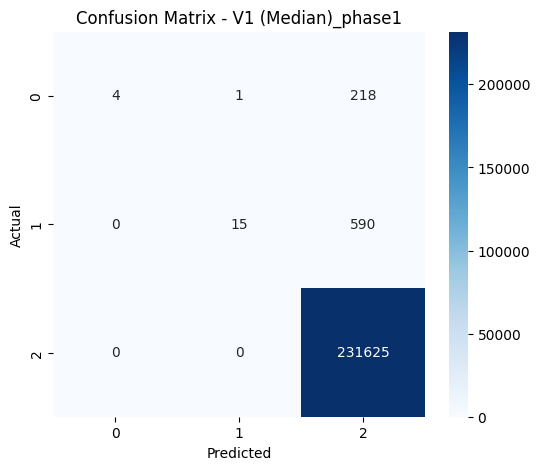

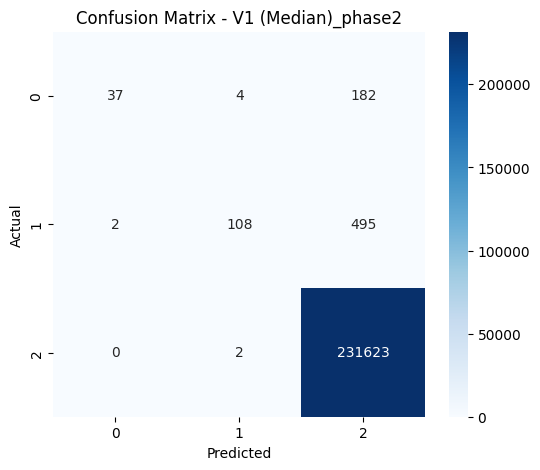

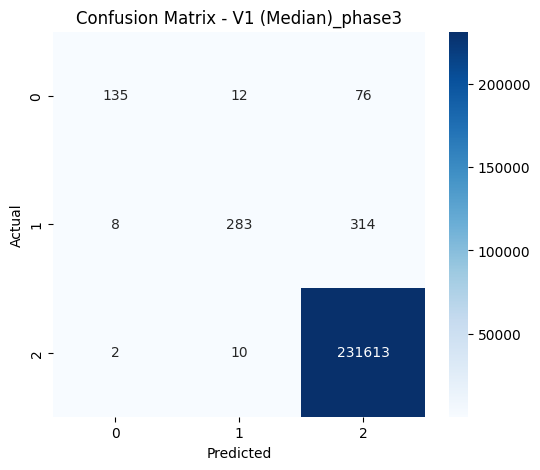

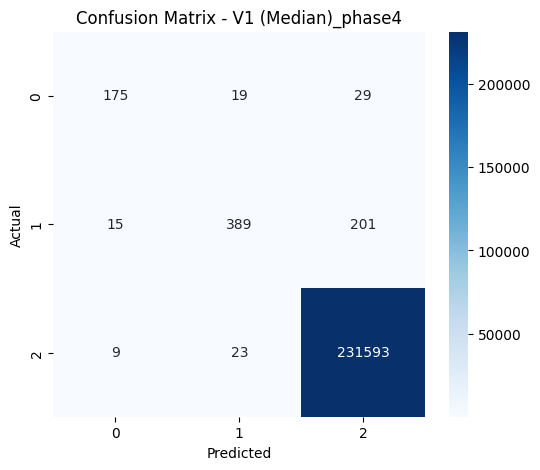

In [8]:
df_v1 = run_experiment(
    base_path=base_path,
    train_file="train_median.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V1 (Median)"
)
df_v1

In [9]:
df_v1.to_csv("results_v1.csv", index=False)

## V2 (Median CDSMOTE)


#####
Version: V2 (Median CDS)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_cdsmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Final X shape: (5791443, 179)
Time Build Model: 511.15s

--- Test Phase 1: /kaggle/input/lo-dataset/Median/Median/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Median/Median/test_1.csv
Time Predict: 0.63s
Saved confusion matrix to: results/confusion_matrix_V2 (Median CDS)_phase1.csv
Saved probability matrix to: results/probability_matrix_V2 (Median CDS)_phase1.csv

============================== V2 (Median CDS) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.1695652174 0.0644628099 0.0934131737       605
     Average  0.9967531209 0.9993264976 0.9980381504    231625

    accuracy                      0.9959346621    232453
   macro avg  0.3887727794 0.3545964358 0.3638171080    232453


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V2 (Median CDS),1,651.802292,0.630784,0.995935,0.354596,0.388773,0.993644,0.354596,0.995935,0.363817,0.994726,0.000000,0.128092,0.105607,0.000000,0.000000,0.000000,0.000000,0.169565,0.064463,0.093413,0.253791,0.996753,0.999326,0.998038,0.298851
1,V2 (Median CDS),2,651.802292,0.653852,0.996464,0.395069,0.697916,0.995190,0.395069,0.996464,0.430238,0.995416,0.337465,0.279680,0.235699,0.764706,0.058296,0.108333,0.241443,0.331897,0.127273,0.183990,0.356634,0.997145,0.999637,0.998389,0.446322
2,V2 (Median CDS),3,651.802292,0.762950,0.997006,0.768587,0.658330,0.997579,0.768587,0.997006,0.701971,0.997254,0.828792,0.637147,0.631947,0.348285,0.591928,0.438538,0.768959,0.627536,0.715702,0.668726,0.845523,0.999170,0.998131,0.998650,0.875603
3,V2 (Median CDS),4,651.802292,0.923930,0.997423,0.895300,0.709926,0.998131,0.895300,0.997423,0.783980,0.997687,0.928249,0.718303,0.705376,0.547278,0.856502,0.667832,0.925159,0.582851,0.831405,0.685286,0.911106,0.999650,0.997992,0.998820,0.948874


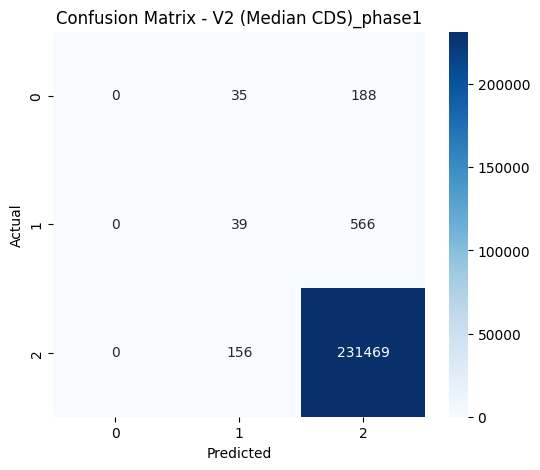

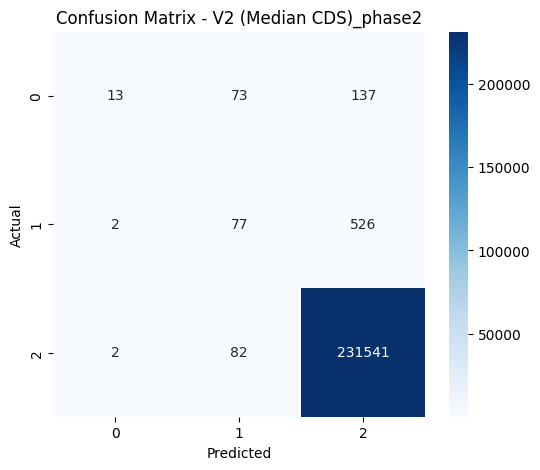

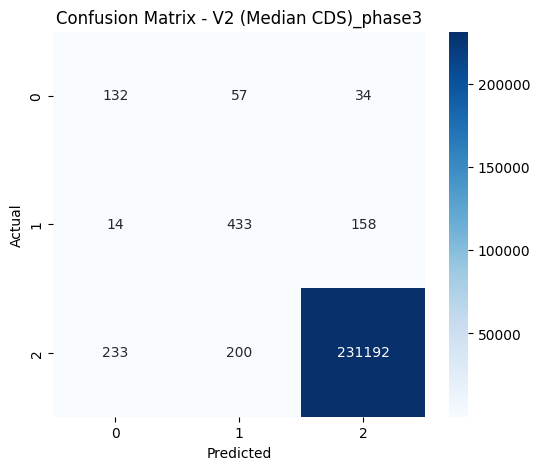

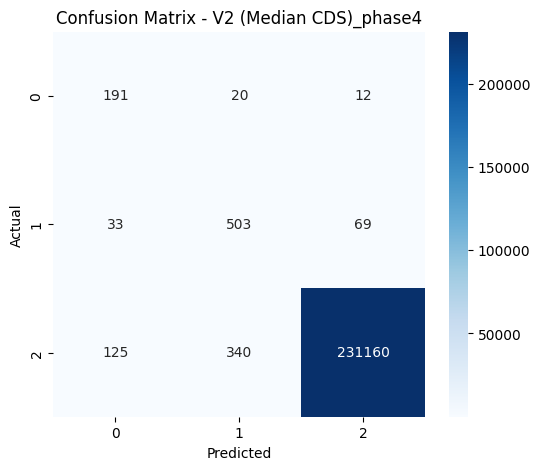

In [10]:
df_v2 = run_experiment(
    base_path=base_path,
    train_file="train_median_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V2 (Median CDS)"
)
df_v2

In [11]:
df_v2.to_csv("results_v2.csv", index=False)

## V3 (Median SASMOTE)


#####
Version: V3 (Median SAS)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_sasmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Final X shape: (5791443, 179)
Time Build Model: 522.50s

--- Test Phase 1: /kaggle/input/lo-dataset/Median/Median/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Median/Median/test_1.csv
Time Predict: 0.69s
Saved confusion matrix to: results/confusion_matrix_V3 (Median SAS)_phase1.csv
Saved probability matrix to: results/probability_matrix_V3 (Median SAS)_phase1.csv

============================== V3 (Median SAS) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.2028985507 0.0462809917 0.0753701211       605
     Average  0.9966941437 0.9996632488 0.9981764883    231625

    accuracy                      0.9962228924    232453
   macro avg  0.3998642315 0.3486480802 0.3578488698    232453


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V3 (Median SAS),1,675.070642,0.693882,0.996223,0.348648,0.399864,0.993672,0.348648,0.996223,0.357849,0.994817,0.000000,0.129131,0.090296,0.000000,0.000000,0.000000,0.000000,0.202899,0.046281,0.075370,0.215079,0.996694,0.999663,0.998176,0.269146
1,V3 (Median SAS),2,675.070642,0.677851,0.996442,0.382649,0.663030,0.994998,0.382649,0.996442,0.411176,0.995312,0.298704,0.258402,0.210620,0.666667,0.035874,0.068085,0.189404,0.325359,0.112397,0.167076,0.335154,0.997063,0.999676,0.998368,0.419847
2,V3 (Median SAS),3,675.070642,0.721923,0.996950,0.753026,0.656812,0.997458,0.753026,0.996950,0.693905,0.997171,0.814181,0.620220,0.616611,0.349081,0.596413,0.440397,0.771865,0.622291,0.664463,0.642686,0.814717,0.999062,0.998204,0.998633,0.858253
3,V3 (Median SAS),4,675.070642,0.973430,0.997440,0.895700,0.713538,0.998130,0.895700,0.997440,0.786766,0.997698,0.928034,0.718890,0.706337,0.559767,0.860987,0.678445,0.927592,0.581206,0.828099,0.683027,0.909291,0.999641,0.998014,0.998827,0.947614


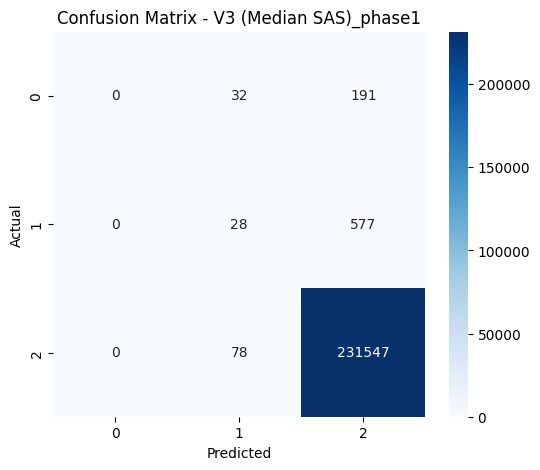

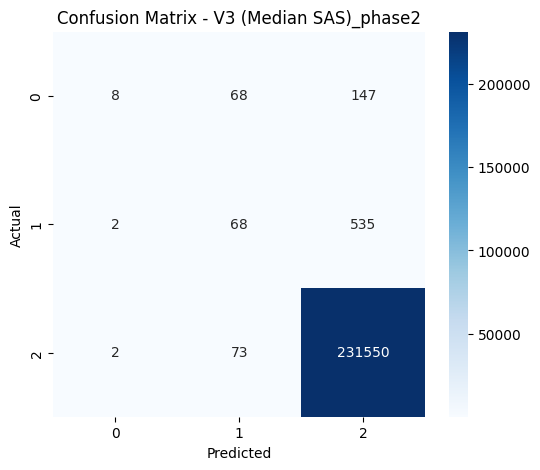

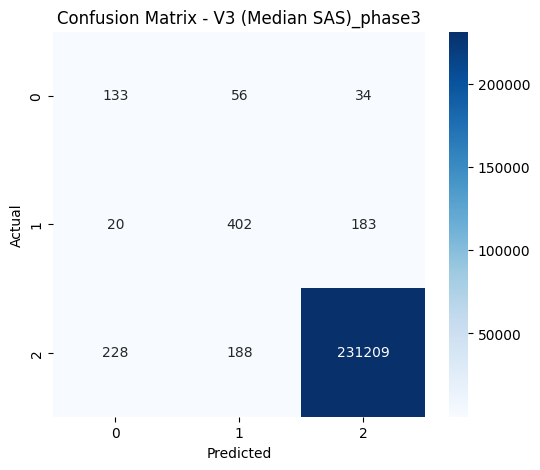

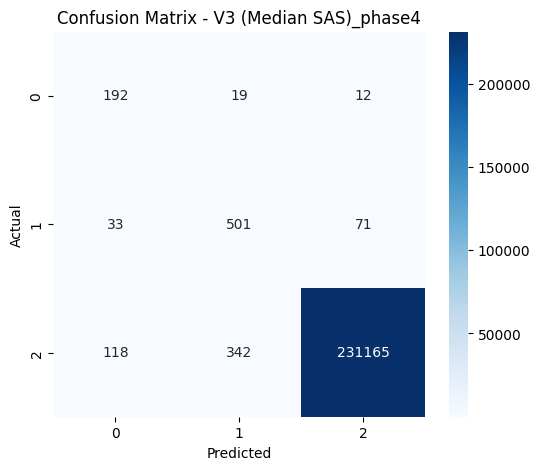

In [12]:
df_v3 = run_experiment(
    base_path=base_path,
    train_file="train_median_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V3 (Median SAS)"
)
df_v3

In [13]:
df_v3.to_csv("results_v3.csv", index=False)

## V4 (Median RadiusSMOTE)


#####
Version: V4 (Median Radius)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_radiussmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Final X shape: (5791443, 179)
Time Build Model: 439.79s

--- Test Phase 1: /kaggle/input/lo-dataset/Median/Median/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Median/Median/test_1.csv
Time Predict: 0.59s
Saved confusion matrix to: results/confusion_matrix_V4 (Median Radius)_phase1.csv
Saved probability matrix to: results/probability_matrix_V4 (Median Radius)_phase1.csv

============================== V4 (Median Radius) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0000000000 0.0000000000 0.0000000000       605
     Average  0.9964379896 1.0000000000 0.9982158172    231625

    accuracy                      0.9964379896    232453
   macro avg  0.3321459965 0.3333333333 0.33273

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V4 (Median Radius),1,592.188761,0.591780,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V4 (Median Radius),2,592.188761,0.614496,0.996494,0.347652,0.835960,0.995461,0.347652,0.996494,0.360529,0.994814,0.141111,0.127336,0.037662,0.875000,0.031390,0.060606,0.177172,0.636364,0.011570,0.022727,0.107564,0.996515,0.999996,0.998252,0.147442
2,V4 (Median Radius),3,592.188761,0.686676,0.997281,0.557659,0.831187,0.996747,0.557659,0.997281,0.641483,0.996704,0.580887,0.506516,0.463051,0.767857,0.385650,0.513433,0.620973,0.728033,0.287603,0.412322,0.536211,0.997669,0.999724,0.998695,0.588662
3,V4 (Median Radius),4,592.188761,0.937639,0.997957,0.788607,0.794159,0.997871,0.788607,0.997957,0.788264,0.997895,0.827670,0.700393,0.699700,0.680934,0.784753,0.729167,0.885707,0.702595,0.581818,0.636528,0.762525,0.998947,0.999249,0.999098,0.839514


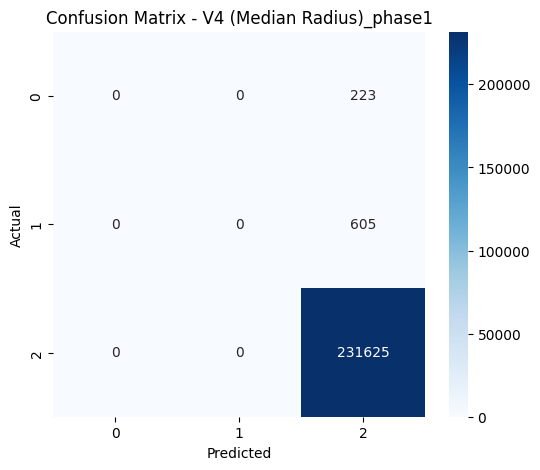

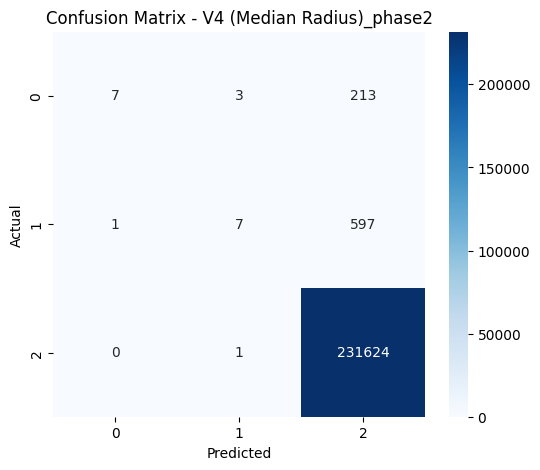

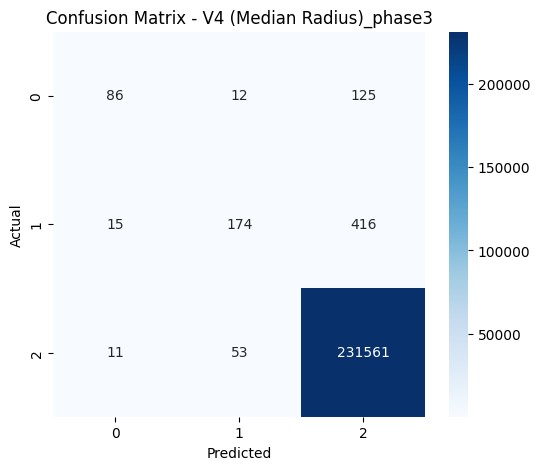

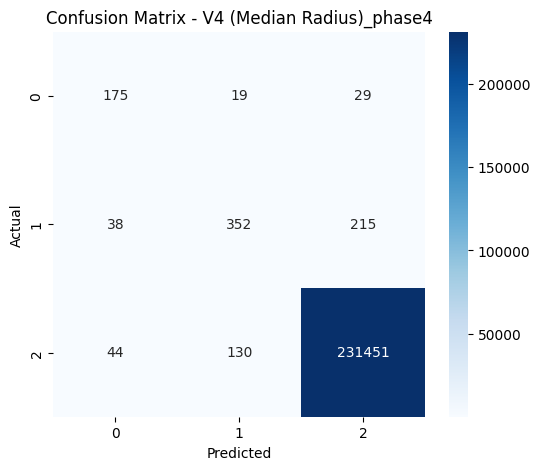

In [14]:
df_v4 = run_experiment(
    base_path=base_path,
    train_file="train_median_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V4 (Median Radius)"
)
df_v4

In [15]:
df_v4.to_csv("results_v4.csv", index=False)

## V5 (Mean)

In [16]:
base_path = "/kaggle/input/lo-dataset/Mean/Mean"


#####
Version: V5 (Mean)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean.csv
Combined train + val: 2092071 samples
Classes: [0 1 2]
Final X shape: (2092071, 179)
Time Build Model: 101.94s

--- Test Phase 1: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv
Time Predict: 0.57s
Saved confusion matrix to: results/confusion_matrix_V5 (Mean)_phase1.csv
Saved probability matrix to: results/probability_matrix_V5 (Mean)_phase1.csv

============================== V5 (Mean) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0000000000 0.0000000000 0.0000000000       605
     Average  0.9964379896 1.0000000000 0.9982158172    231625

    accuracy                      0.9964379896    232453
   macro avg  0.3321459965 0.3333333333 0.3327386057    232453
weighted avg  0.9928886671 0.9964379896 0.9946

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V5 (Mean),1,185.685504,0.565159,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V5 (Mean),2,185.685504,0.572047,0.996696,0.381492,0.998898,0.996707,0.381492,0.996696,0.422610,0.995270,0.268909,0.268833,0.134800,1.000000,0.071749,0.133891,0.267860,1.000000,0.072727,0.135593,0.269680,0.996695,1.000000,0.998345,0.269191
2,V5 (Mean),3,185.685504,0.578938,0.997905,0.655351,0.926430,0.997682,0.655351,0.997905,0.750244,0.997564,0.692629,0.645849,0.613654,0.937500,0.538117,0.683761,0.733552,0.843648,0.428099,0.567982,0.654225,0.998142,0.999836,0.998988,0.692380
3,V5 (Mean),4,185.685504,0.952254,0.998714,0.808404,0.921445,0.998622,0.808404,0.998714,0.857748,0.998617,0.846076,0.802463,0.795818,0.878173,0.775785,0.823810,0.880741,0.887133,0.649587,0.750000,0.805883,0.999029,0.999840,0.999435,0.853314


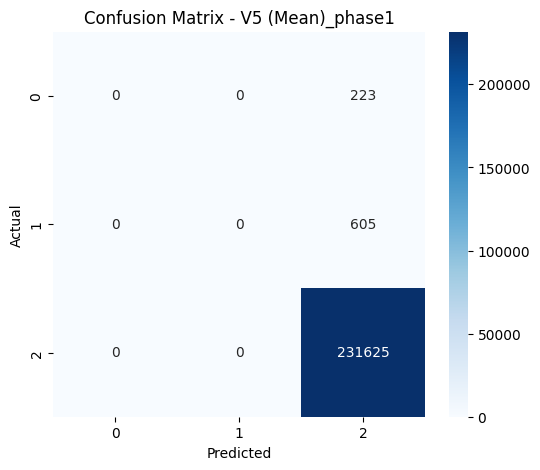

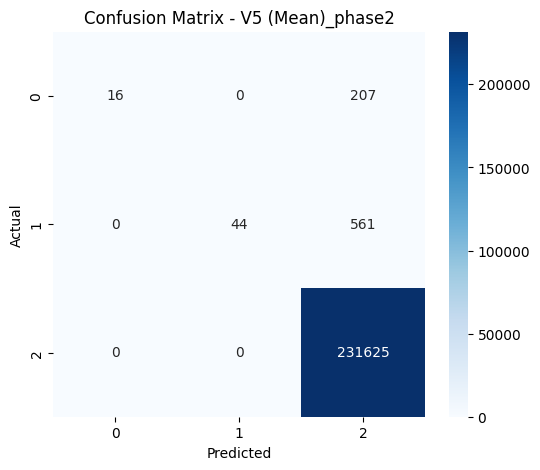

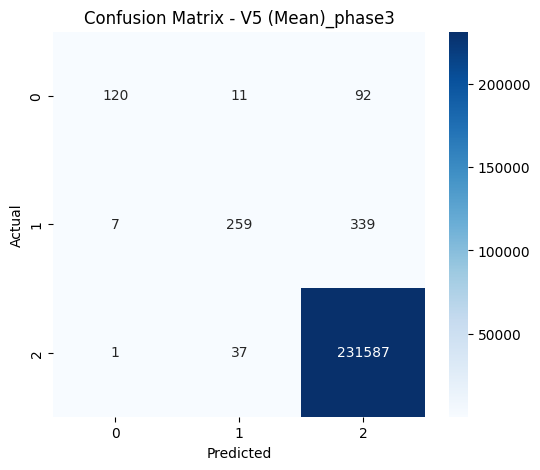

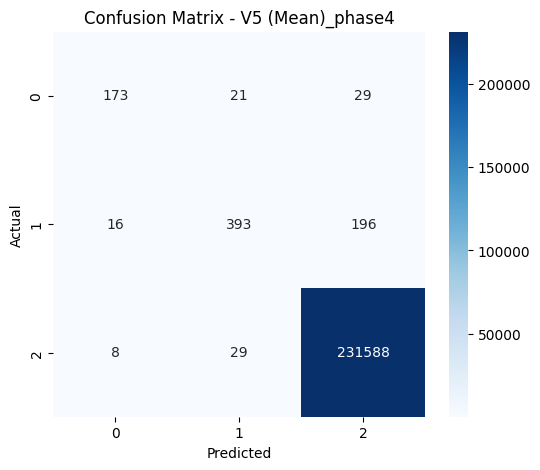

In [17]:
df_v5 = run_experiment(
    base_path=base_path,
    train_file="train_mean.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V5 (Mean)"
)
df_v5

In [18]:
df_v5.to_csv("results_v5.csv", index=False)

## V6 (Mean CDSMOTE)


#####
Version: V6 (Mean CDS)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_cdsmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Final X shape: (5791443, 179)
Time Build Model: 503.05s

--- Test Phase 1: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv
Time Predict: 0.60s
Saved confusion matrix to: results/confusion_matrix_V6 (Mean CDS)_phase1.csv
Saved probability matrix to: results/probability_matrix_V6 (Mean CDS)_phase1.csv

============================== V6 (Mean CDS) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0862745098 0.0727272727 0.0789237668       605
     Average  0.9967750697 0.9981435510 0.9974588410    231625

    accuracy                      0.9947774389    232453
   macro avg  0.3610165265 0.3569569412 0.3587942026    232453
weighted avg  0.993449

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V6 (Mean CDS),1,738.57676,0.596071,0.994777,0.356957,0.361017,0.993449,0.356957,0.994777,0.358794,0.994111,0.000000,0.093226,0.090539,0.000000,0.000000,0.000000,0.000000,0.086275,0.072727,0.078924,0.269409,0.996775,0.998144,0.997459,0.310546
1,V6 (Mean CDS),2,738.57676,0.643729,0.990794,0.374153,0.681935,0.994607,0.374153,0.990794,0.358143,0.992182,0.215729,0.097213,0.092647,1.000000,0.004484,0.008929,0.066965,0.048733,0.123967,0.069963,0.350976,0.997072,0.994008,0.995538,0.427171
2,V6 (Mean CDS),3,738.57676,0.705783,0.990592,0.647120,0.451774,0.995660,0.647120,0.990592,0.504424,0.992845,0.711811,0.331008,0.292429,0.166667,0.403587,0.235911,0.634670,0.190092,0.545455,0.281931,0.736306,0.998562,0.992319,0.995431,0.771772
3,V6 (Mean CDS),4,738.57676,0.961614,0.997531,0.903818,0.718847,0.998204,0.903818,0.997531,0.793167,0.997778,0.934184,0.729439,0.716702,0.561047,0.865471,0.680776,0.930004,0.595819,0.847934,0.699864,0.920142,0.999676,0.998049,0.998861,0.952704


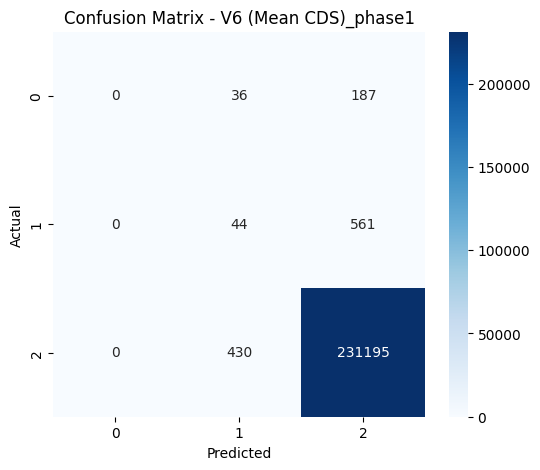

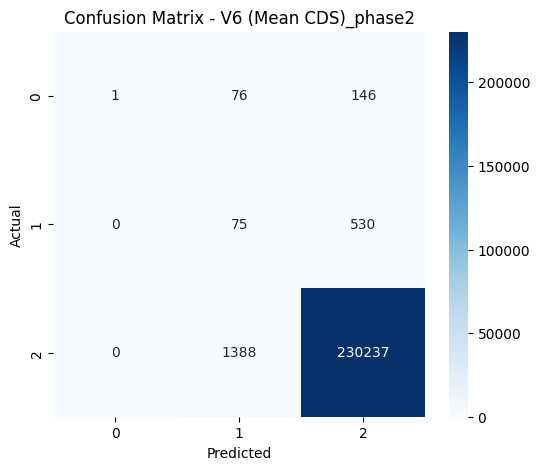

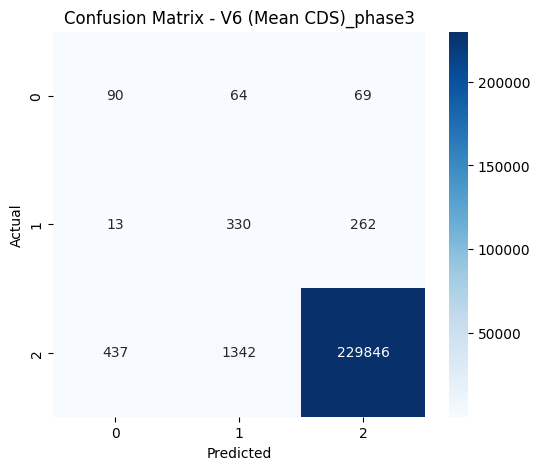

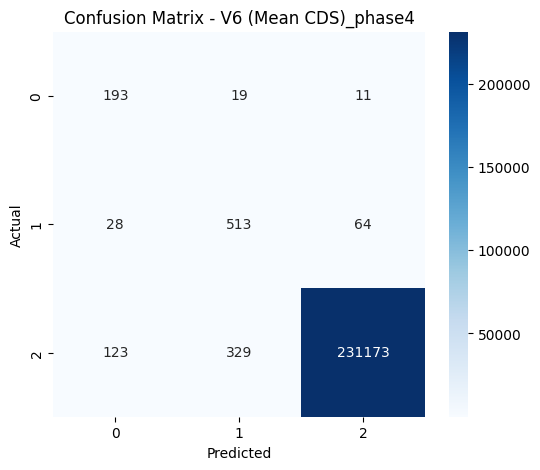

In [19]:
df_v6 = run_experiment(
    base_path=base_path,
    train_file="train_mean_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V6 (Mean CDS)"
)
df_v6

In [20]:
df_v6.to_csv("results_v6.csv", index=False)

## V7 (Mean SASMOTE)


#####
Version: V7 (Mean SAS)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_sasmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Final X shape: (5791443, 179)
Time Build Model: 492.26s

--- Test Phase 1: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv
Time Predict: 0.59s
Saved confusion matrix to: results/confusion_matrix_V7 (Mean SAS)_phase1.csv
Saved probability matrix to: results/probability_matrix_V7 (Mean SAS)_phase1.csv

============================== V7 (Mean SAS) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0495767836 0.0677685950 0.0572625698       605
     Average  0.9967836081 0.9967879115 0.9967857598    231625

    accuracy                      0.9934137223    232453
   macro avg  0.3487867972 0.3548521688 0.3513494432    232453
weighted avg  0.993362

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V7 (Mean SAS),1,728.612651,0.589440,0.993414,0.354852,0.348787,0.993362,0.354852,0.993414,0.351349,0.993384,0.000000,0.072075,0.072066,0.000000,0.000000,0.000000,0.000000,0.049577,0.067769,0.057263,0.259882,0.996784,0.996788,0.996786,0.316101
1,V7 (Mean SAS),2,728.612651,0.627073,0.994029,0.366048,0.359337,0.993660,0.366048,0.994029,0.362333,0.993842,0.000000,0.120190,0.120045,0.000000,0.000000,0.000000,0.000000,0.081009,0.100826,0.089838,0.317058,0.997000,0.997319,0.997160,0.400247
2,V7 (Mean SAS),3,728.612651,0.686640,0.995784,0.657662,0.576593,0.996463,0.657662,0.995784,0.608999,0.996096,0.719456,0.485118,0.481217,0.260054,0.434978,0.325503,0.659136,0.471182,0.540496,0.503464,0.734602,0.998544,0.997513,0.998028,0.769104
3,V7 (Mean SAS),4,728.612651,0.945138,0.997509,0.900824,0.713283,0.998207,0.900824,0.997509,0.788148,0.997766,0.933585,0.728519,0.715353,0.545714,0.856502,0.666667,0.925157,0.594438,0.847934,0.698910,0.920138,0.999697,0.998036,0.998866,0.955856


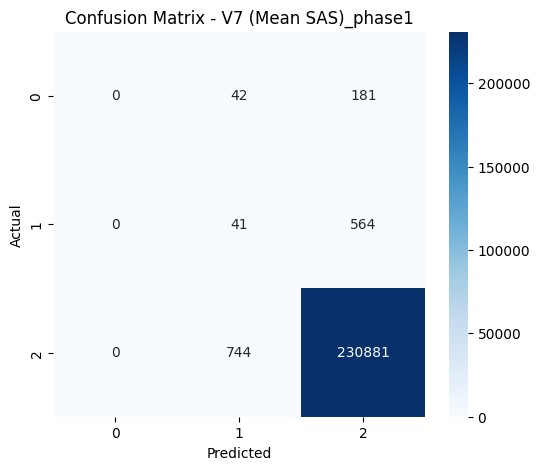

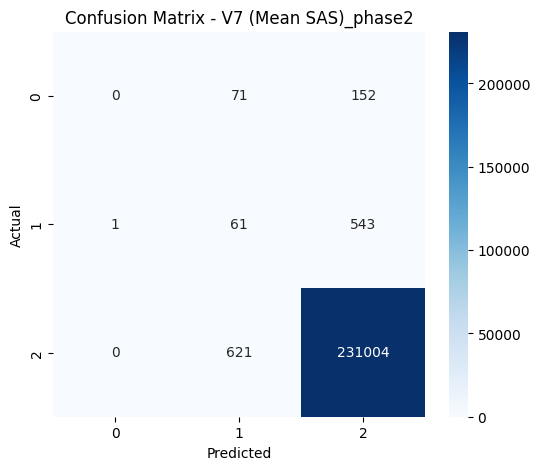

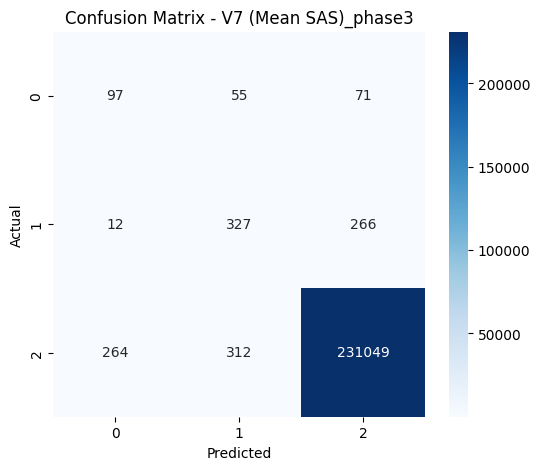

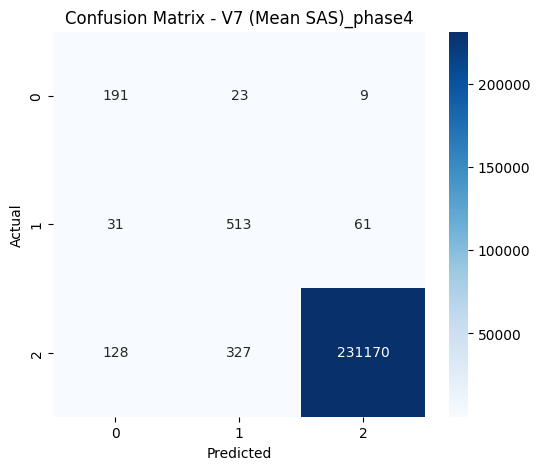

In [21]:
df_v7 = run_experiment(
    base_path=base_path,
    train_file="train_mean_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V7 (Mean SAS)"
)
df_v7

In [22]:
df_v7.to_csv("results_v7.csv", index=False)

## V8 (Mean RadiusSMOTE)


#####
Version: V8 (Mean Radius)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_radiussmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Final X shape: (5791443, 179)
Time Build Model: 403.36s

--- Test Phase 1: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Mean/Mean/test_1.csv
Time Predict: 0.67s
Saved confusion matrix to: results/confusion_matrix_V8 (Mean Radius)_phase1.csv
Saved probability matrix to: results/probability_matrix_V8 (Mean Radius)_phase1.csv

============================== V8 (Mean Radius) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0714285714 0.0066115702 0.0121028744       605
     Average  0.9964629492 0.9997841338 0.9981207788    231625

    accuracy                      0.9962401001    232453
   macro avg  0.3559638402 0.3354652347 0.3367412177    232453
weight

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V8 (Mean Radius),1,637.386643,0.671938,0.996240,0.335465,0.355964,0.993099,0.335465,0.996240,0.336741,0.994597,0.000000,0.022453,0.010926,0.000000,0.000000,0.000000,0.000000,0.071429,0.006612,0.012103,0.081302,0.996463,0.999784,0.998121,0.085116
1,V8 (Mean Radius),2,637.386643,0.602391,0.993452,0.342465,0.671438,0.993986,0.342465,0.993452,0.344658,0.993252,0.133067,0.022199,0.022155,1.000000,0.008969,0.017778,0.094703,0.017784,0.021488,0.019461,0.146359,0.996530,0.996939,0.996735,0.169991
2,V8 (Mean Radius),3,637.386643,0.640105,0.996124,0.509165,0.601673,0.995229,0.509165,0.996124,0.513783,0.995360,0.462076,0.290549,0.273919,0.334507,0.426009,0.374753,0.652428,0.473282,0.102479,0.168478,0.320076,0.997229,0.999007,0.998117,0.472449
3,V8 (Mean Radius),4,637.386643,0.896378,0.997875,0.802150,0.770839,0.997910,0.802150,0.997875,0.784938,0.997888,0.846906,0.704818,0.704756,0.645038,0.757848,0.696907,0.870370,0.668367,0.649587,0.658843,0.805630,0.999111,0.999016,0.999063,0.866296


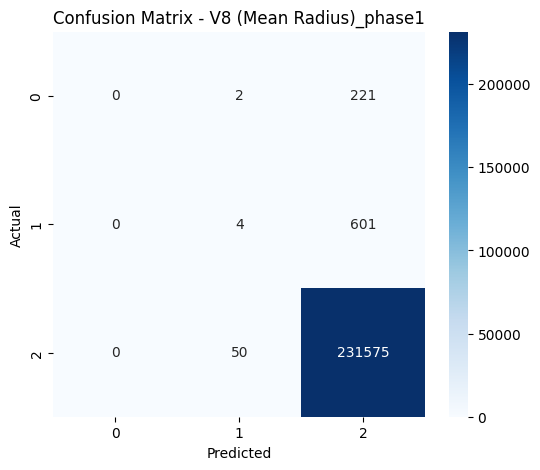

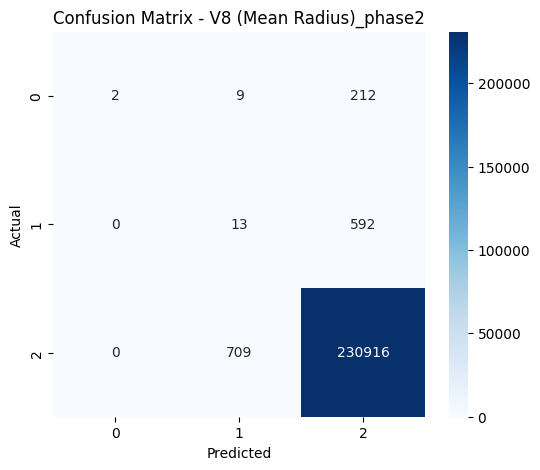

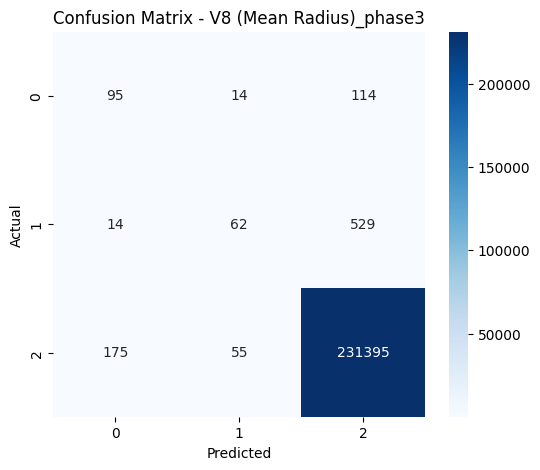

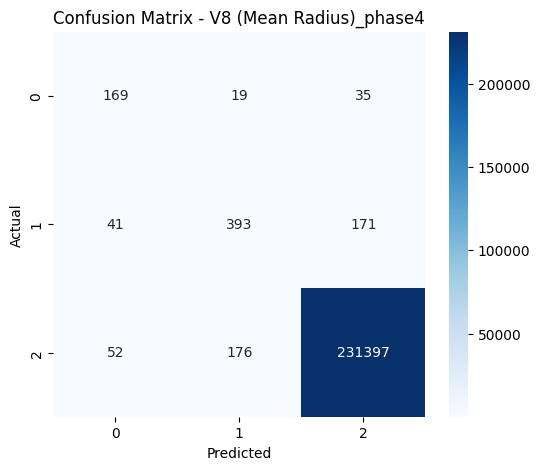

In [23]:
df_v8 = run_experiment(
    base_path=base_path,
    train_file="train_mean_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V8 (Mean Radius)"
)
df_v8

In [24]:
df_v8.to_csv("results_v8.csv", index=False)

## V9 (Extra Trees)

In [25]:
base_path = "/kaggle/input/lo-dataset/Extra_trees/Extra_trees"


#####
Version: V9 (Extra)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra.csv
Combined train + val: 2092071 samples
Classes: [0 1 2]
Final X shape: (2092071, 179)
Time Build Model: 145.68s

--- Test Phase 1: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv
Time Predict: 0.56s
Saved confusion matrix to: results/confusion_matrix_V9 (Extra)_phase1.csv
Saved probability matrix to: results/probability_matrix_V9 (Extra)_phase1.csv

============================== V9 (Extra) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0000000000 0.0000000000 0.0000000000       605
     Average  0.9964379896 1.0000000000 0.9982158172    231625

    accuracy                      0.9964379896    232453
   macro avg  0.3321459965 0.3333333333 0.3327386057    232453

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V9 (Extra),1,229.769106,0.559898,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V9 (Extra),2,229.769106,0.578956,0.996451,0.337818,0.665484,0.993861,0.337818,0.996451,0.341590,0.994692,0.000000,0.060143,0.007204,1.000000,0.013453,0.026549,0.115987,0.000000,0.000000,0.000000,0.000000,0.996451,1.000000,0.998222,0.060193
2,V9 (Extra),3,229.769106,0.613440,0.997320,0.502670,0.973146,0.997218,0.502670,0.997320,0.600755,0.996530,0.505402,0.497216,0.403120,0.966667,0.260090,0.409894,0.509988,0.955414,0.247934,0.393701,0.497922,0.997356,0.999987,0.998670,0.508381
3,V9 (Extra),4,229.769106,1.032258,0.998744,0.822164,0.919023,0.998663,0.822164,0.998744,0.864421,0.998657,0.855948,0.808161,0.802610,0.865385,0.807175,0.835267,0.898375,0.892617,0.659504,0.758555,0.812015,0.999068,0.999814,0.999441,0.859647


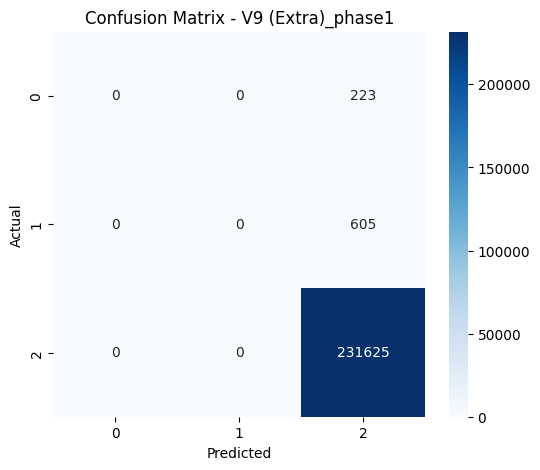

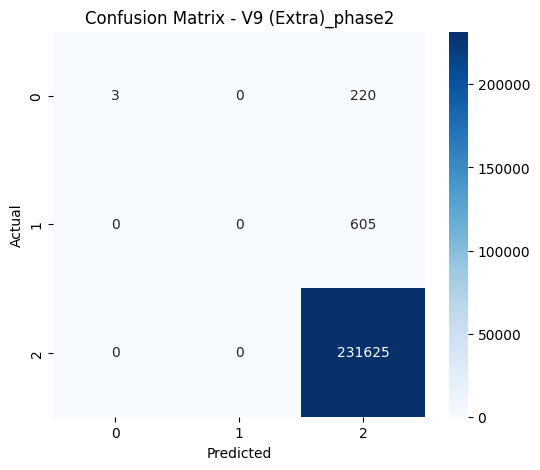

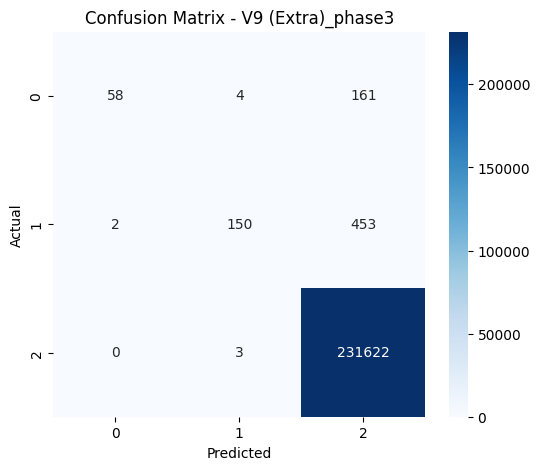

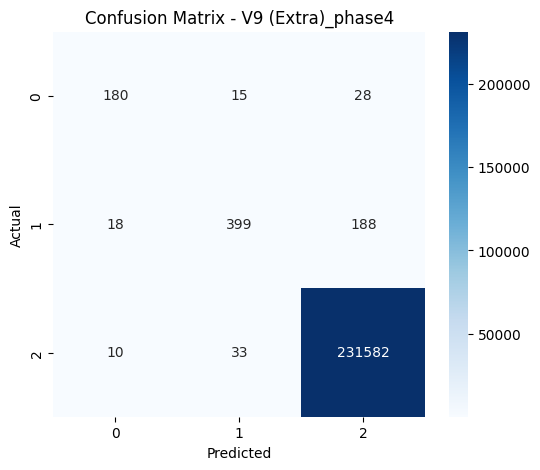

In [26]:
df_v9 = run_experiment(
    base_path=base_path,
    train_file="train_extra.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V9 (Extra)"
)
df_v9

In [27]:
df_v9.to_csv("results_v9.csv", index=False)

## V10 (Extra Trees CDSMOTE)


#####
Version: V10 (Extra CDS)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_cdsmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Final X shape: (5791443, 179)
Time Build Model: 614.11s

--- Test Phase 1: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv
Time Predict: 0.57s
Saved confusion matrix to: results/confusion_matrix_V10 (Extra CDS)_phase1.csv
Saved probability matrix to: results/probability_matrix_V10 (Extra CDS)_phase1.csv

============================== V10 (Extra CDS) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0000000000 0.0000000000 0.0000000000       605
     Average  0.9964379896 1.0000000000 0.9982158172    231625

    accuracy                      0.9964379896    232453
   macro avg  0.3321459965 0.33333

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V10 (Extra CDS),1,860.751886,0.571968,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V10 (Extra CDS),2,860.751886,0.611609,0.996421,0.334976,0.373837,0.993287,0.334976,0.996421,0.335925,0.994706,0.000000,0.070518,0.023305,0.000000,0.000000,0.000000,0.000000,0.125000,0.004959,0.009539,0.070415,0.996511,0.999970,0.998237,0.143286
2,V10 (Extra CDS),3,860.751886,0.701671,0.995337,0.427508,0.478217,0.995036,0.427508,0.995337,0.444347,0.995122,0.402449,0.270592,0.268785,0.044164,0.062780,0.051852,0.250396,0.392962,0.221488,0.283298,0.470415,0.997524,0.998256,0.997890,0.553379
3,V10 (Extra CDS),4,860.751886,0.903217,0.998030,0.895587,0.765808,0.998366,0.895587,0.998030,0.821888,0.998159,0.925668,0.761234,0.755735,0.636066,0.869955,0.734848,0.932491,0.661765,0.818182,0.731707,0.904040,0.999594,0.998623,0.999108,0.940879


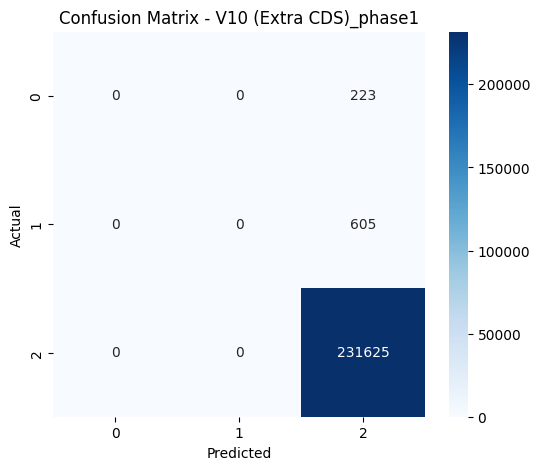

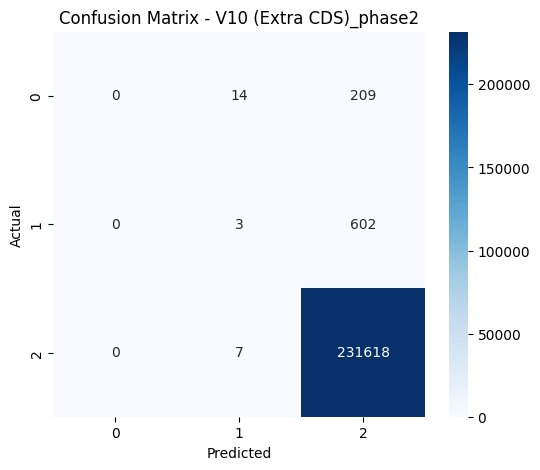

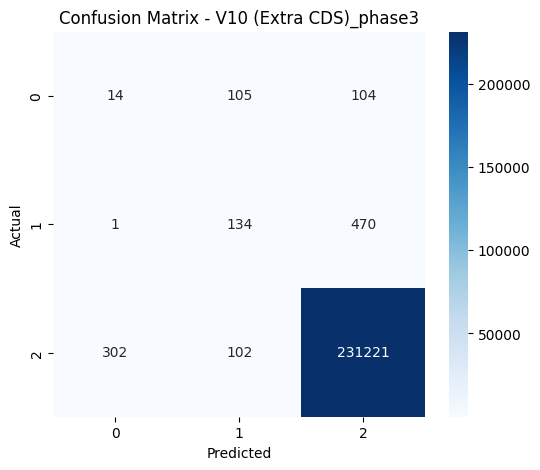

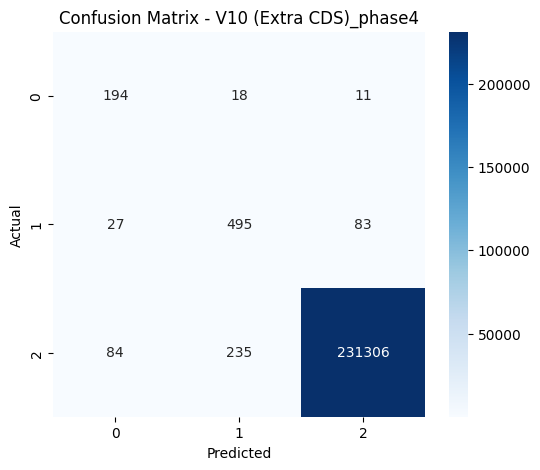

In [28]:
df_v10 = run_experiment(
    base_path=base_path,
    train_file="train_extra_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V10 (Extra CDS)"
)
df_v10

In [29]:
df_v10.to_csv("results_v10.csv", index=False)

## V11 (Extra Trees SASMOTE)


#####
Version: V11 (Extra SAS)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_sasmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Final X shape: (5791443, 179)
Time Build Model: 617.51s

--- Test Phase 1: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv
Time Predict: 0.59s
Saved confusion matrix to: results/confusion_matrix_V11 (Extra SAS)_phase1.csv
Saved probability matrix to: results/probability_matrix_V11 (Extra SAS)_phase1.csv

============================== V11 (Extra SAS) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0000000000 0.0000000000 0.0000000000       605
     Average  0.9964379896 1.0000000000 0.9982158172    231625

    accuracy                      0.9964379896    232453
   macro avg  0.3321459965 0.33333

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V11 (Extra SAS),1,836.431168,0.588529,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V11 (Extra SAS),2,836.431168,0.604263,0.996438,0.333333,0.332150,0.992901,0.333333,0.996438,0.332741,0.994667,0.000000,0.029954,0.003588,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996451,1.000000,0.998222,0.060193
2,V11 (Extra SAS),3,836.431168,0.704778,0.995780,0.406703,0.490475,0.994714,0.406703,0.995780,0.429226,0.995095,0.364620,0.229535,0.217519,0.086124,0.080717,0.083333,0.283991,0.388128,0.140496,0.206311,0.374719,0.997173,0.998895,0.998033,0.455522
3,V11 (Extra SAS),4,836.431168,0.893949,0.997982,0.889287,0.761234,0.998324,0.889287,0.997982,0.816579,0.998115,0.921348,0.755148,0.749735,0.629508,0.860987,0.727273,0.927668,0.654618,0.808264,0.723373,0.898535,0.999576,0.998610,0.999093,0.938305


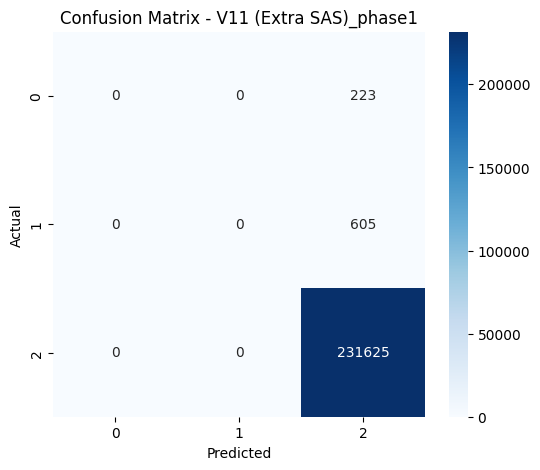

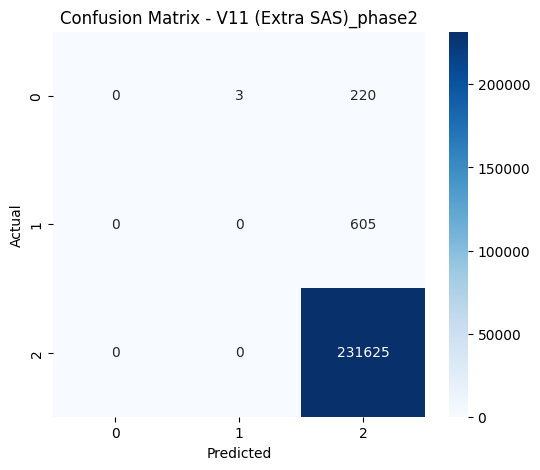

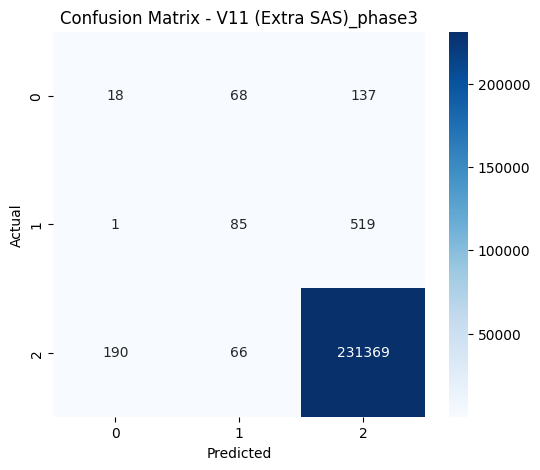

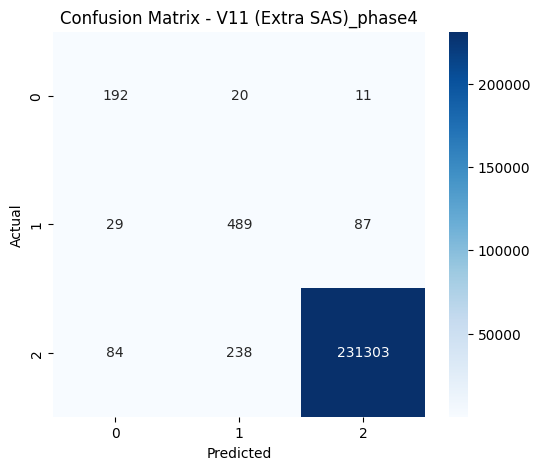

In [30]:
df_v11 = run_experiment(
    base_path=base_path,
    train_file="train_extra_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V11 (Extra SAS)"
)
df_v11

In [31]:
df_v11.to_csv("results_v11.csv", index=False)

## V12 (Extra Trees RadiusSMOTE)


#####
Version: V12 (Extra Radius)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_radiussmote.csv
Combined train + val: 5791443 samples
Classes: [0 1 2]
Final X shape: (5791443, 179)
Time Build Model: 542.88s

--- Test Phase 1: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv ---

Evaluating: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/test_1.csv
Time Predict: 0.61s
Saved confusion matrix to: results/confusion_matrix_V12 (Extra Radius)_phase1.csv
Saved probability matrix to: results/probability_matrix_V12 (Extra Radius)_phase1.csv

============================== V12 (Extra Radius) - Phase 1 ==============================
              precision    recall  f1-score   support

   Excellent  0.0000000000 0.0000000000 0.0000000000       223
        Good  0.0000000000 0.0000000000 0.0000000000       605
     Average  0.9964379896 1.0000000000 0.9982158172    231625

    accuracy                      0.9964379896    232453
   macro avg  0.33

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V12 (Extra Radius),1,854.543567,0.611805,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V12 (Extra Radius),2,854.543567,0.641238,0.996339,0.338246,0.372207,0.993384,0.338246,0.996339,0.341570,0.994752,0.000000,0.103572,0.057103,0.000000,0.000000,0.000000,0.000000,0.120000,0.014876,0.026471,0.121950,0.996622,0.999862,0.998239,0.227871
2,V12 (Extra Radius),3,854.543567,0.747660,0.996520,0.358424,0.820290,0.995202,0.358424,0.996520,0.380493,0.994925,0.190288,0.161717,0.067729,1.000000,0.053812,0.102128,0.231973,0.464286,0.021488,0.041074,0.146582,0.996584,0.999974,0.998276,0.202637
3,V12 (Extra Radius),4,854.543567,1.018121,0.998262,0.817762,0.821892,0.998210,0.817762,0.998262,0.817582,0.998223,0.855982,0.747419,0.746970,0.710317,0.802691,0.753684,0.895789,0.756238,0.651240,0.699822,0.806773,0.999119,0.999357,0.999238,0.867835


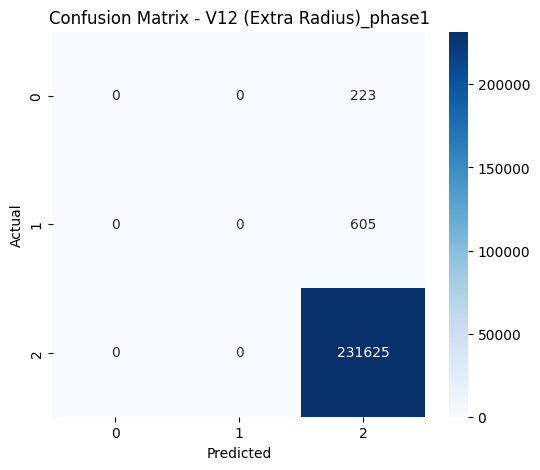

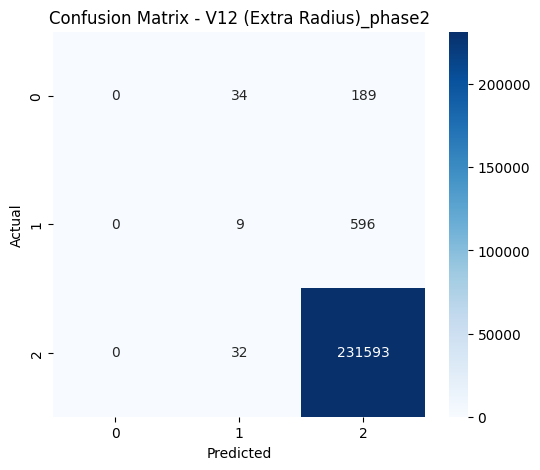

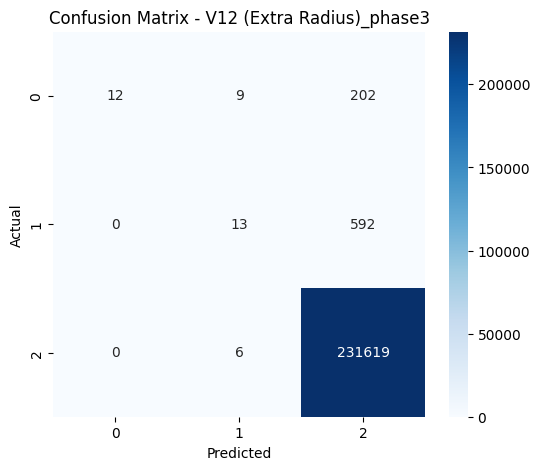

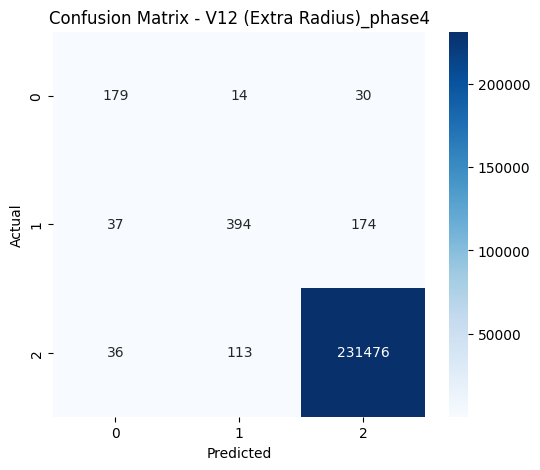

In [32]:
df_v12 = run_experiment(
    base_path=base_path,
    train_file="train_extra_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V12 (Extra Radius)"
)
df_v12

In [33]:
df_v12.to_csv("results_v12.csv", index=False)